In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 300

# Memastikan folder output tersedia
os.makedirs('../output', exist_ok=True)

print("Memuat hasil evaluasi model...")

# Fungsi pembantu untuk memuat file JSON
def load_metrics(filepath):
    if os.path.exists(filepath):
        with open(filepath, 'r') as f:
            return json.load(f)
    else:
        print(f"Peringatan: File {filepath} tidak ditemukan!")
        return None

# Load metrik XGBoost dan LSTM
metrics_xgb = load_metrics('../processed/xgb_metrics.json')
metrics_lstm = load_metrics('../processed/lstm_metrics.json')

if metrics_xgb and metrics_lstm:
    print("Berhasil memuat metrik kedua model!")
    print(f"XGBoost R2: {metrics_xgb['R2']:.4f}")
    print(f"LSTM R2   : {metrics_lstm['R2']:.4f}")

Memuat hasil evaluasi model...
Berhasil memuat metrik kedua model!
XGBoost R2: 0.8187
LSTM R2   : 0.8642


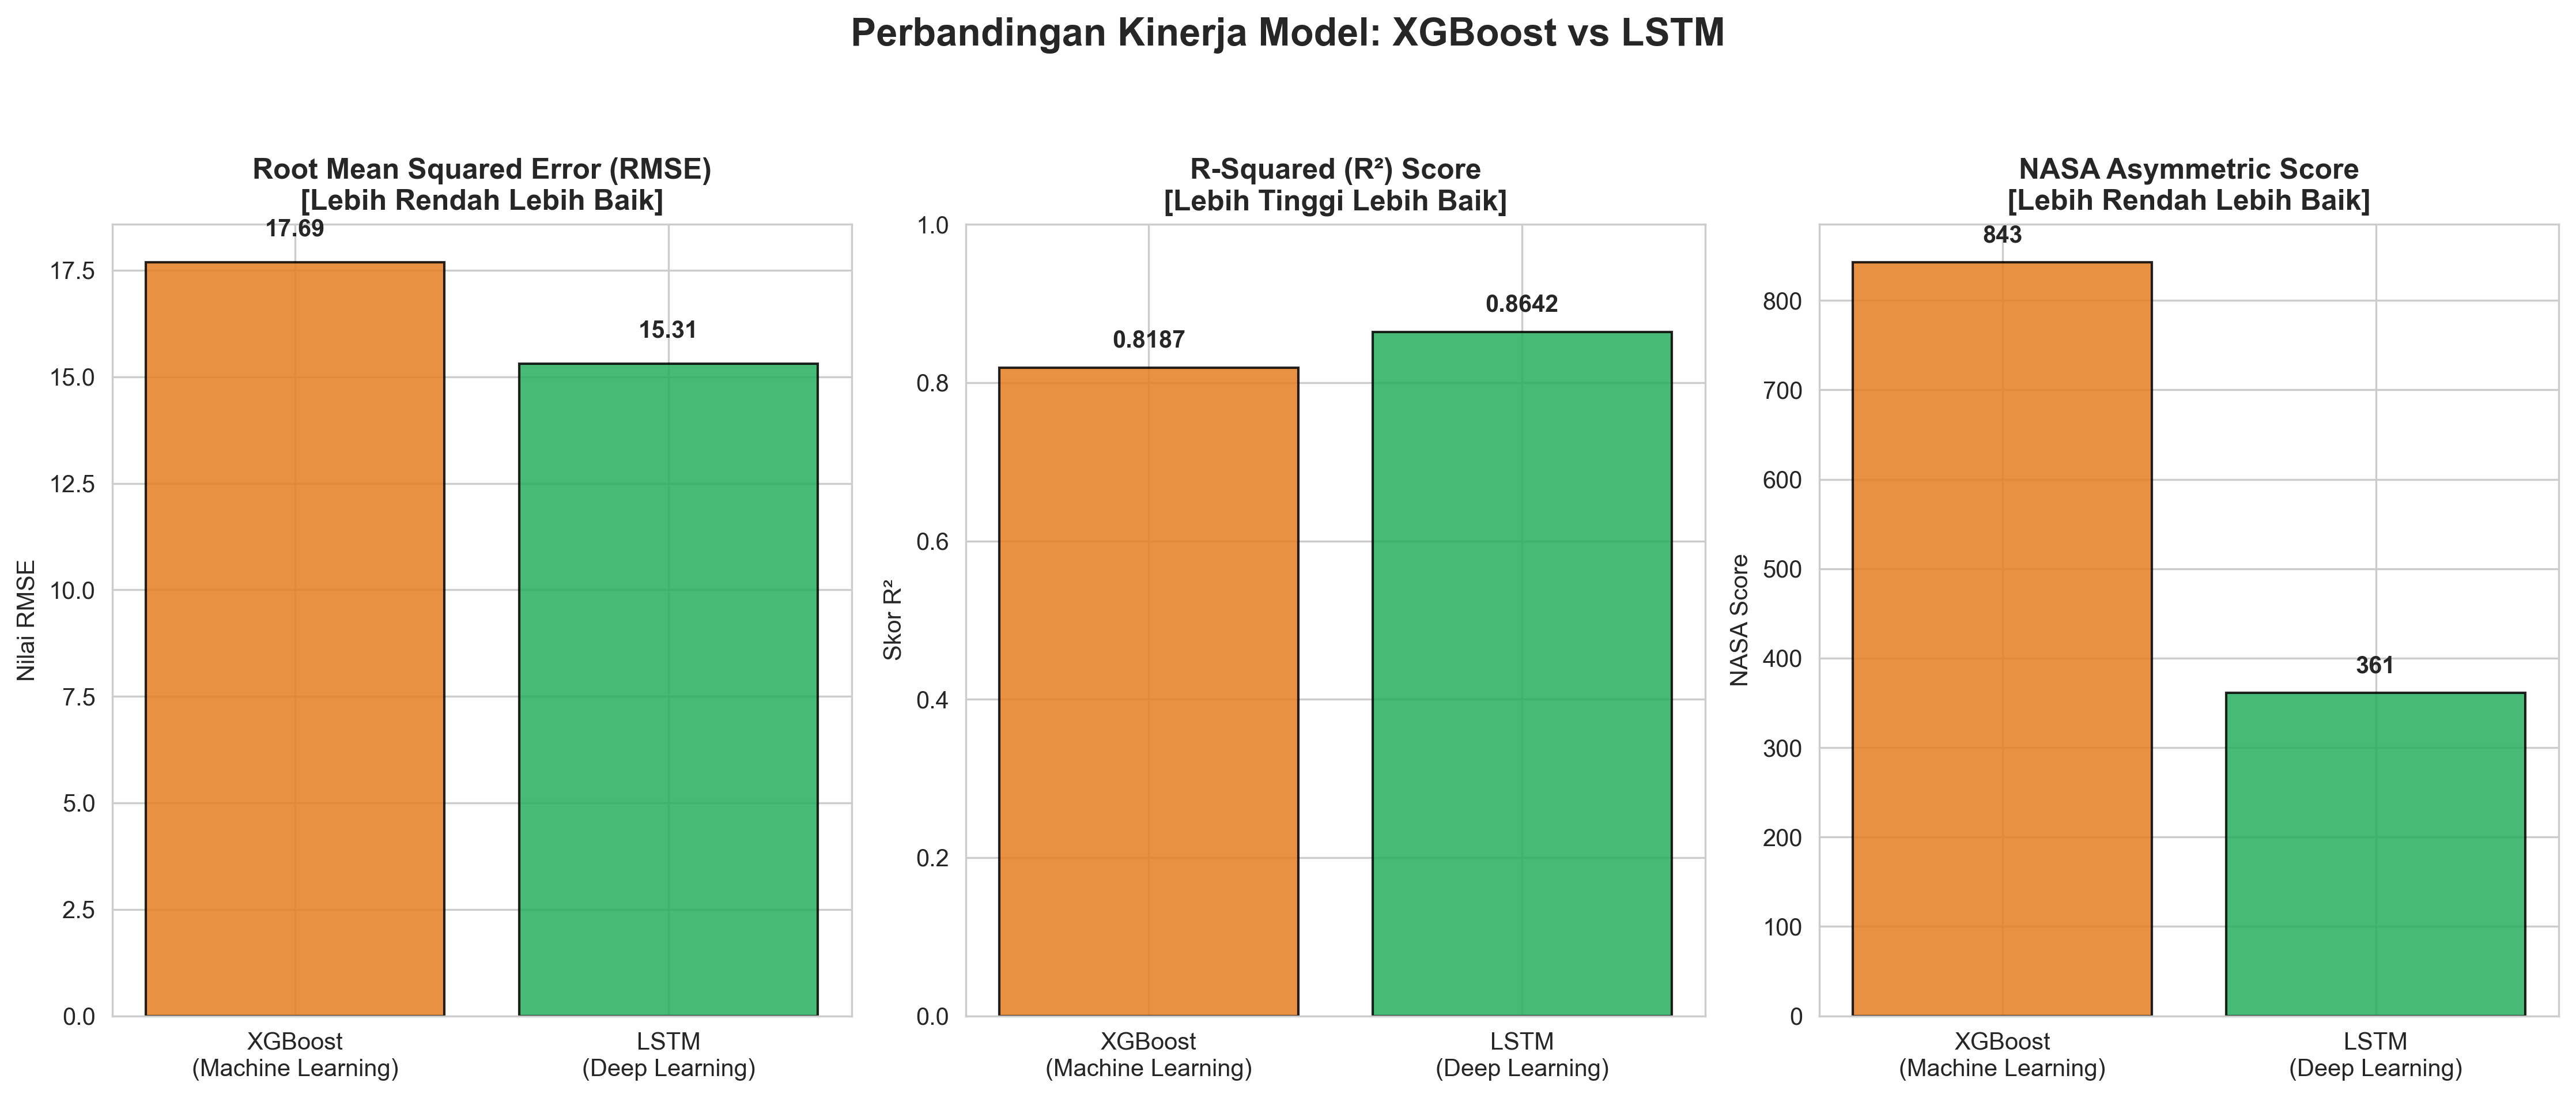

In [4]:
if not (metrics_xgb and metrics_lstm):
    print("Harap pastikan file JSON dari kedua model sudah tersedia.")
else:
    models = ['XGBoost\n(Machine Learning)', 'LSTM\n(Deep Learning)']
    
    rmse_scores = [metrics_xgb['RMSE'], metrics_lstm['RMSE']]
    r2_scores = [metrics_xgb['R2'], metrics_lstm['R2']]
    nasa_scores = [metrics_xgb['NASA_Score'], metrics_lstm['NASA_Score']]
    fig, axes = plt.subplots(1, 3, figsize=(15, 6))
    colors = ['#E67E22', '#27AE60'] 

    # 1. Plot RMSE (Lebih rendah lebih baik)
    bars1 = axes[0].bar(models, rmse_scores, color=colors, alpha=0.85, edgecolor='black')
    axes[0].set_title('Root Mean Squared Error (RMSE)\n[Lebih Rendah Lebih Baik]', fontweight='bold')
    axes[0].set_ylabel('Nilai RMSE')

    for bar in bars1:
        yval = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval:.2f}', ha='center', va='bottom', fontweight='bold')

    # 2. Plot R2 Score (Lebih tinggi lebih baik)
    bars2 = axes[1].bar(models, r2_scores, color=colors, alpha=0.85, edgecolor='black')
    axes[1].set_title('R-Squared (R²) Score\n[Lebih Tinggi Lebih Baik]', fontweight='bold')
    axes[1].set_ylabel('Skor R²')
    axes[1].set_ylim(0, 1.0) 
    
    for bar in bars2:
        yval = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')

    # 3. Plot NASA Score (Lebih rendah lebih baik)
    bars3 = axes[2].bar(models, nasa_scores, color=colors, alpha=0.85, edgecolor='black')
    axes[2].set_title('NASA Asymmetric Score\n[Lebih Rendah Lebih Baik]', fontweight='bold')
    axes[2].set_ylabel('NASA Score')
    
    for bar in bars3:
        yval = bar.get_height()
        axes[2].text(bar.get_x() + bar.get_width()/2, yval + (max(nasa_scores)*0.02), f'{yval:.0f}', ha='center', va='bottom', fontweight='bold')

    plt.suptitle('Perbandingan Kinerja Model: XGBoost vs LSTM', fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.savefig('../output/final_model_comparison.png', bbox_inches='tight', dpi=300)
    plt.show()